# **Small optimized models for COBOL code documentation generation**

**COBOL** est un langage ancien et peu répandu aujourd’hui, mais il reste largement utilisé, notamment dans le secteur bancaire. La donnée disponible autour de ce langage est limitée, en particulier la documentation à partir de code existant. Ce notebook explore cette problématique en s’appuyant sur de petits modèles de langage, afin de tester des **approches légères**, **accessibles**, **peu couteuses en calcul** et potentiellement intégrables dans des environnements contraints — comme ceux où tournent encore ces systèmes legacy.

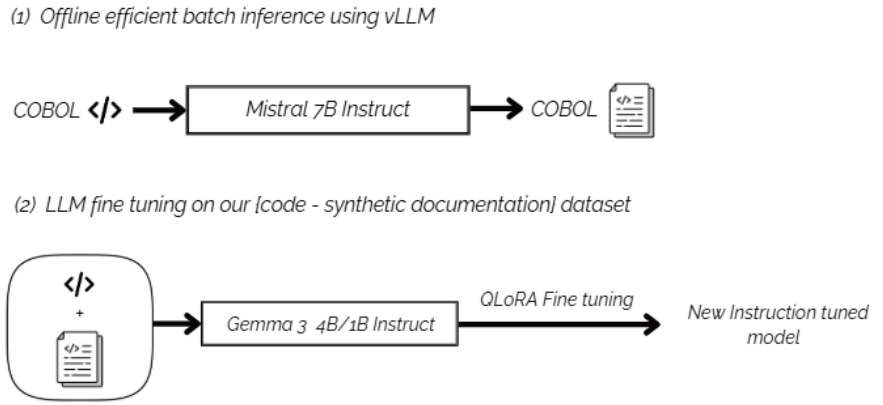

In [3]:
from IPython.display import Image, display
display(Image(filename='cobol_pipelines.png', width=700))

L’approche suivie repose sur deux grandes étapes complémentaires. Dans un premier temps, des fragments de code COBOL réels sont utilisés comme base pour générer automatiquement des descriptions sous forme de documentation technique, à l’aide de *vLLM* et du modèle *Mistral 7B Instruct*. Cette génération en batch permet de créer un jeu de données [code ↔ documentation] dans lequel seule la partie **documentation** est **synthétique**. L’intérêt de cette démarche est double : pallier l’**absence de données annotées sur COBOL**, tout en conservant des **exemples de code authentiques** pour rester proche des cas d’usage réels. Cela permet de constituer rapidement un volume significatif de données adaptées à la tâche, tout en gardant un bon niveau de réalisme.

Dans un second temps, ce dataset est utilisé pour entraîner un **modèle léger** (Gemma 3B et 1B Instruct) via un fine-tuning basé sur QLoRA. Le but est de créer un modèle capable de comprendre et de documenter du code COBOL, tout en étant facilement déployable dans des environnements contraints.

### *(1) vLLM : generation de documentations synthetiques de code COBOL avec Mistral 7B Instruct v0.3*

In [ ]:
!pip install vllm datasets tqdm transformers

import json
from datetime import datetime
from datasets import load_dataset, Dataset, DatasetDict
from tqdm import tqdm
from vllm import LLM, SamplingParams
from huggingface_hub import login

def setup_model():
    """
    Charge le modèle Mistral 7B Instruct pour la génération de documentation de code COBOL.
    """
    return LLM(
        model="mistralai/Mistral-7B-Instruct-v0.3",
        tensor_parallel_size=1,
        max_model_len=8192,
        gpu_memory_utilization=0.9
    )

dataset = load_dataset("MaIlz/cobol_dataset3")

prompt_template = """
You are an expert COBOL developer tasked with creating professional, structured, and complete documentation from the provided COBOL program source code.

Structure your documentation strictly as follows:

## Program Overview
Provide a clear, concise summary (1-3 sentences) of the program's purpose and main functionality. Explicitly state the inputs and outputs of the program, including their format and source/destination.

## Data Definitions and Variables
List clearly and precisely:
- Each critical data item or variable, including its COBOL declaration (PIC clause, etc.).
- For each variable, specify:
  - Its role in the program (e.g., input, output, temporary storage).
  - Its initial value, if applicable.
  - How it is used or modified throughout the program.
- If variables are part of a larger structure (e.g., records, groups), explain their relationships.

## Main Logic and Workflow
Provide a clear, step-by-step explanation of the program's execution:
- Outline the logical sequence of operations in the order they occur.
- Describe any key algorithms, business rules, or computations in detail. Include formulas or examples where appropriate (e.g., for calculations like mortgage payments).
- Clearly explain any conditions, loops, or decision-making processes, including their purpose and outcomes.

## Detailed Code Breakdown
For each significant procedure, paragraph, or logic block:
- Provide the exact COBOL code snippet (fully included, no abrupt cut-off).
- Explain:
  - What the block does and its purpose in the overall program.
  - Any inputs it requires and outputs it produces.
  - Critical logic, including computations, conditions, and decision-making.
- If the block interacts with other parts of the program, describe those interactions.

Ensure all explanations are accurate, complete, and free of assumptions. If there are any unclear or potentially erroneous parts in the code, highlight them and suggest possible corrections or clarifications.

COBOL Program:
{content}

Structured Documentation:
"""

llm = setup_model()

output_file = f"results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.jsonl"

batch_size = 2
sampling_params = SamplingParams(temperature=0.1, top_p=0.9, max_tokens=2048)

with open(output_file, 'w') as f:
    for i in tqdm(range(0, len(dataset['train']), batch_size)):
        batch = dataset['train'][i:i + batch_size]
        inputs = [prompt_template.format(content=content_sample) for content_sample in batch['content']]

        try:
            outputs = llm.generate(inputs, sampling_params)
            for j, out in enumerate(outputs):
                json.dump({"idx": i+j, "documentation": out.outputs[0].text}, f)
                f.write('\n')
            f.flush()
        except Exception as e:
            print(f"Le batch {i//batch_size} a échoué: {e}")

documentation_elements = []
with open(output_file, 'r') as f:
    for line in f:
        result = json.loads(line)
        documentation_elements.append(result['documentation'])

assert len(documentation_elements) == len(dataset['train']), (
    f"Le nombre d'éléments générés ({len(documentation_elements)}) ne correspond pas à la taille du dataset ({len(dataset['train'])})"
)

new_dataset_dict = DatasetDict()
for split in dataset.keys():
    split_dict = dataset[split].to_dict()
    if split == 'train':
        split_dict['documentation'] = documentation_elements
    new_dataset_dict[split] = Dataset.from_dict(split_dict)

print("Nouvelle structure du DatasetDict:")
print(new_dataset_dict)
print("\nNombre d'exemples par split:")
for split in new_dataset_dict:
    print(f"{split}: {len(new_dataset_dict[split])} exemples")
print("\nColonnes du split 'train':", new_dataset_dict['train'].column_names)

new_dataset_dict.push_to_hub("MaIlz/cobol_doc_data", private=True)

### *(2) Fine tuning avec TRL et gemma3 (1B/4B) instruct avec notre dataset semi-synthétique*

In [ ]:
!pip install transformers datasets torch peft bitsandbytes trl gradio

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
import torch
from huggingface_hub import login

dataset = load_dataset('MaIlz/cobol_doc_data')

def process_example(example):
    code = example['content']
    documentation = example['documentation']
    prompt = f"Generate documentation for the following COBOL code:\n\n{code}\n\nDocumentation:"
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": documentation}
    ]
    return {"messages": messages}

dataset_split = dataset['train'].train_test_split(test_size=0.1)
train_dataset = dataset_split['train'].map(process_example)
eval_dataset = dataset_split['test'].map(process_example)

model_name = "google/gemma-3-4b-it"

config = AutoConfig.from_pretrained(model_name)
config.text_config.use_cache = False

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=4e-5,
    bf16=True,
    logging_steps=10,
    save_steps=100,
    eval_steps=50,
    evaluation_strategy="steps",
    load_best_model_at_end=True,
    report_to="tensorboard",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
)

trainer.train()

#trainer.push_to_hub("")

#model = model.merge_and_unload()
#model.save_pretrained("./fine_tuned_cobol_model")
#tokenizer.save_pretrained("./fine_tuned_cobol_model")

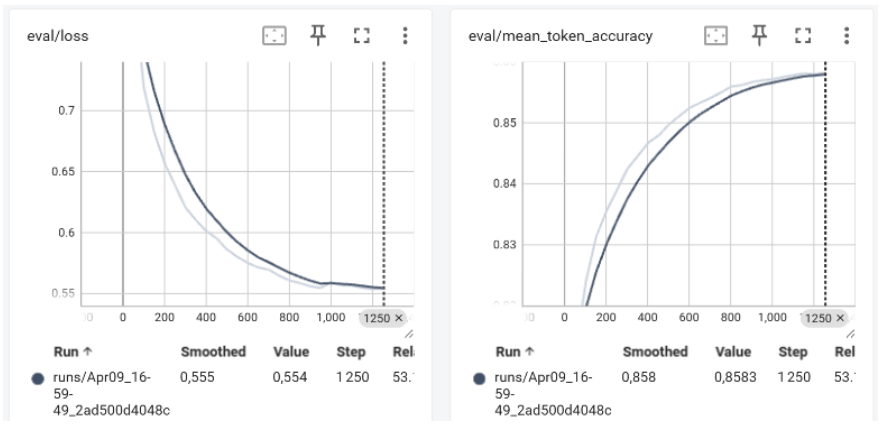

In [4]:
from IPython.display import Image, display
display(Image(filename='cobol_curves.png', width=700))

### *Test*

In [ ]:
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig, TrainingArguments
import torch

finetuned_model_path = "MaIlz/gemma3_4b_cobol_"

tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
model = AutoModelForCausalLM.from_pretrained(finetuned_model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

code = """
       IDENTIFICATION DIVISION.
       PROGRAM-ID. BonjourNom.

       ENVIRONMENT DIVISION.

       DATA DIVISION.
       WORKING-STORAGE SECTION.
       01 NOM-UTILISATEUR     PIC A(30).
       01 FIN-LIGNE           PIC X VALUE X"0A".

       PROCEDURE DIVISION.
       AFFICHAGE-DEBUT.
           DISPLAY "Entrez votre nom : "
           ACCEPT NOM-UTILISATEUR
           DISPLAY "Bonjour, " NOM-UTILISATEUR " !".

           STOP RUN.
"""

messages = [
    {"role": "user", "content": f"Step by step, for **each code bloc**, generate the most complete, accurate and well formatted documentation (I don't want variables or lines in title) for each code bloc of the following COBOL code:\n\n{code}\n\nDocumentation:"}
]

inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt", return_dict=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

input_length = inputs['input_ids'].shape[1]

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=2048, do_sample=True, temperature=0.7)

generated_ids = outputs[0, input_length:]
generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

if generated_text.startswith("model\n"):
    generated_text = generated_text[len("model\n"):]

print("Generated text:", generated_text)

In [ ]:
import gradio as gr
from huggingface_hub import login
from transformers import TextIteratorStreamer
import torch
from threading import Thread
from functools import lru_cache

@lru_cache(maxsize=2)
def load_model(model_path: str):
    tokenizer_local = AutoTokenizer.from_pretrained(model_path)
    model_local = AutoModelForCausalLM.from_pretrained(model_path)
    device_local = "cuda" if torch.cuda.is_available() else "cpu"
    model_local.to(device_local)
    model_local.eval()
    return tokenizer_local, model_local, device_local

model_options = [
    "MaIlz/gemma3_4b_cobol_",
    "MaIlz/gemma3_1b_cobol_it"
]

default_cobol_code = """
       IDENTIFICATION DIVISION.
       PROGRAM-ID. BonjourNom.

       ENVIRONMENT DIVISION.

       DATA DIVISION.
       WORKING-STORAGE SECTION.
       01 NOM-UTILISATEUR     PIC A(30).

       PROCEDURE DIVISION.
       AFFICHAGE-DEBUT.
           DISPLAY "Entrez votre nom : "
           ACCEPT NOM-UTILISATEUR
           DISPLAY "Bonjour, " NOM-UTILISATEUR " !".

           STOP RUN.
"""

def generate_documentation(model_choice, cobol_code):
    tokenizer, model, device = load_model(model_choice)

    messages = [
        {"role": "user", "content": (
            "Step by step, for **each code bloc**, generate the most complete, accurate and well formatted documentation "
            "(I don't want variables or lines in title) for each code bloc of the following COBOL code:\n\n"
            f"{cobol_code}\n\nDocumentation:"
        )}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    streamer = TextIteratorStreamer(tokenizer, skip_prompt=True)

    generation_kwargs = dict(
        **inputs,
        streamer=streamer,
        max_new_tokens=2048,
        do_sample=True,
        temperature=0.7
    )
    def run_generation():
        with torch.no_grad():
            model.generate(**generation_kwargs)

    thread = Thread(target=run_generation)
    thread.start()

    generated = ""
    for new_text in streamer:
        generated += new_text
        yield generated

iface = gr.Interface(
    fn=generate_documentation,
    inputs=[
        gr.Dropdown(choices=model_options, label="Sélectionnez votre modèle"),
        gr.Textbox(lines=15, label="Entrez votre code COBOL", value=default_cobol_code)
    ],
    outputs=gr.Textbox(lines=20, label="Documentation générée"),
    title="Générateur de Documentation COBOL",
    description="Générez une documentation complète pour votre code COBOL",
    allow_flagging="never"
)
iface.launch()
